# WiniCari -- 10 Fondation : Avant / Après Enrichissement

Mesure l'impact RÉEL de l'enrichissement (`src/data/stations.py`) sur la fondation, en
exécutant le pipeline de reconstruction de trajets (`foundation.reconstruct_bus_day`) sur un
échantillon récent de jours, une fois avec les lignes utilisables d'AVANT, une fois avec
celles d'APRÈS enrichissement.

Avant de lancer un calcul coûteux, on vérifie d'abord que les lignes récupérées appartiennent
à des sociétés qui ont réellement des pings GPS récents -- sinon la coordonnée récupérée ne
sert à rien pour la fondation (elle ne pourrait servir qu'à d'éventuelles futures données).


---
## 0. Configuration

In [1]:
from pathlib import Path
import sys, os, time
sys.path.insert(0, str(Path.cwd().parent))
os.environ.setdefault("PYTHONIOENCODING", "utf-8")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient
from IPython.display import display

from src.data import stations as st
from src.data import foundation as fdn

client = MongoClient()
wi  = client["winicari"]
od  = client["OpenData"]
tk  = client["Historique_Tickets"]
gps = client["Historique_pos"]

CACHE_DIR = Path.cwd().parent / "models" / "cache"
cfg = fdn.Config()


---
## 1. Lignes utilisables -- avant vs après enrichissement

`foundation.build_usable_lines` accepte maintenant des paramètres d'enrichissement optionnels
(`ticket_index`, `od_dict`) -- sans eux, comportement identique à avant (rétrocompatible).

In [2]:
od_dict = st.opendata_dict(od)
ticket_index = st.load_or_build_ticket_index(tk, CACHE_DIR / "ticket_stop_index.parquet")

t0 = time.time()
usable_before = fdn.build_usable_lines(wi, cfg)
print(f"AVANT enrichissement : {len(usable_before)} lignes utilisables ({time.time()-t0:.1f}s)")

t0 = time.time()
usable_after = fdn.build_usable_lines(wi, cfg, ticket_index=ticket_index, od_dict=od_dict)
print(f"APRÈS enrichissement : {len(usable_after)} lignes utilisables ({time.time()-t0:.1f}s)")

new_keys = set(usable_after) - set(usable_before)
print(f"\nNouvelles lignes récupérées : {len(new_keys)}")

rows_before = sum(len(sf) for sf in usable_before.values())
rows_after  = sum(len(sf) for sf in usable_after.values())
print(f"Lignes d'arrêts mappées -- avant : {rows_before}, après : {rows_after} (+{rows_after-rows_before})")


AVANT enrichissement : 143 lignes utilisables (1.1s)


APRÈS enrichissement : 187 lignes utilisables (5.8s)

Nouvelles lignes récupérées : 44
Lignes d'arrêts mappées -- avant : 2067, après : 2383 (+316)


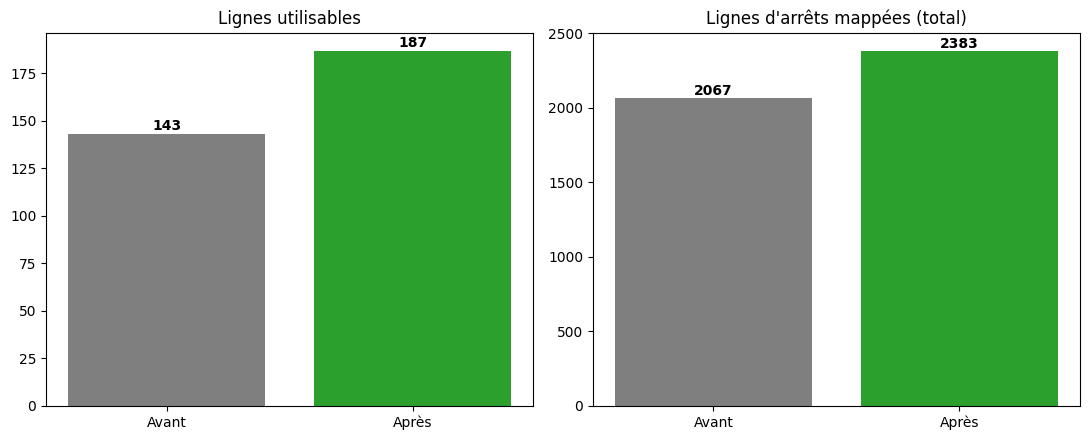

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
axes[0].bar(["Avant", "Après"], [len(usable_before), len(usable_after)], color=["#7f7f7f", "#2ca02c"])
axes[0].set_title("Lignes utilisables")
for i, v in enumerate([len(usable_before), len(usable_after)]):
    axes[0].text(i, v+2, str(v), ha="center", fontweight="bold")

axes[1].bar(["Avant", "Après"], [rows_before, rows_after], color=["#7f7f7f", "#2ca02c"])
axes[1].set_title("Lignes d'arrêts mappées (total)")
for i, v in enumerate([rows_before, rows_after]):
    axes[1].text(i, v+20, str(v), ha="center", fontweight="bold")
plt.tight_layout(); plt.show()


### 1.1 Les lignes récupérées appartiennent-elles à des sociétés avec GPS actif ?

Récupérer des coordonnées ne sert à rien si la société n'a aucun ping GPS -- on vérifie ça
avant d'aller plus loin.

In [4]:
days_all = fdn.gps_days(gps, cfg)
recent_days = days_all[-10:]
soc_gps_days = {}
for day in recent_days:
    for soc in gps[day].distinct("service.societe"):
        if soc:
            soc_gps_days[soc] = soc_gps_days.get(soc, 0) + 1

new_by_soc = {}
for (code_, soc) in new_keys:
    new_by_soc[soc] = new_by_soc.get(soc, 0) + 1

rows = []
for soc, n in sorted(new_by_soc.items(), key=lambda x: -x[1]):
    rows.append({"societe": soc, "lignes_recuperees": n,
                 "jours_gps_actifs_10j": soc_gps_days.get(soc, 0)})
df_soc = pd.DataFrame(rows)
display(df_soc)

n_gps_active = sum(r["lignes_recuperees"] for r in rows if r["jours_gps_actifs_10j"] > 0)
print(f"\nLignes récupérées appartenant à une société avec GPS actif récent : "
      f"{n_gps_active} / {len(new_keys)}")


,societe,lignes_recuperees,jours_gps_actifs_10j
0,S.T.S,21,1
1,SRT.ELGOUAFEL,16,10
2,S.R.T.SELIANA,3,10
3,S.R.T.M,2,0
4,S.R.T.K,1,10
5,Winicari,1,0



Lignes récupérées appartenant à une société avec GPS actif récent : 41 / 44


---
## 2. Reconstruction réelle de trajets -- échantillon de jours récents

On exécute le vrai pipeline (`candidates_for_day` + `reconstruct_bus_day`) sur les 30 derniers
jours GPS disponibles, avec le dictionnaire de lignes APRÈS enrichissement (qui contient les
lignes d'avant + les nouvelles). Chaque trajet produit est étiqueté `recuperee` selon que sa
ligne existait déjà avant l'enrichissement ou non -- ça permet de comparer la qualité
(`match_rate`, `dist_m`) des nouvelles lignes à celle des lignes déjà utilisées par la
fondation en production.

In [5]:
sample_days = days_all[-30:]
print(f"Échantillon : {len(sample_days)} jours ({sample_days[0]} -> {sample_days[-1]})")

t0 = time.time()
frames = []
n_cand = 0
for day in sample_days:
    for (dy, line, soc, bus) in fdn.candidates_for_day(gps, day, usable_after, cfg):
        n_cand += 1
        try:
            f = fdn.reconstruct_bus_day(gps, dy, line, soc, bus, usable_after[(line, soc)], cfg)
        except Exception:
            continue
        if len(f):
            f["recuperee"] = (line, soc) in new_keys
            frames.append(f)

sample = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"\nCandidats (jour,ligne,societe,bus) testés : {n_cand}")
print(f"Lignes d'arrivée produites : {len(sample):,} en {time.time()-t0:.0f}s")
if len(sample):
    print(f"Dont sur des lignes récupérées : {sample['recuperee'].sum():,} "
          f"({100*sample['recuperee'].mean():.1f}%)")


Échantillon : 30 jours (d20260523 -> d20260621)



Candidats (jour,ligne,societe,bus) testés : 319
Lignes d'arrivée produites : 9,838 en 77s
Dont sur des lignes récupérées : 5,955 (60.5%)


### 2.1 Qualité comparée -- `match_rate` et `dist_m`, lignes récupérées vs déjà utilisées

Si les nouvelles lignes produisent un taux de correspondance nettement plus faible ou des
distances aberrantes, l'enrichissement ajouterait du volume mais dégraderait la qualité
moyenne -- c'est le test qui tranche.

In [6]:
if len(sample):
    taux = sample.groupby("recuperee")["matched"].agg(["count","mean"])
    # dist_m d'un arrêt NON correspondu est non borné par construction (ping loin de tout arrêt
    # attendu) -- le mélanger aux arrêts correspondus fausserait totalement la p90/médiane.
    # On restreint donc les stats de distance aux arrêts EFFECTIVEMENT correspondus.
    dist_matched = (sample[sample["matched"]].groupby("recuperee")["dist_m"]
                    .agg(dist_m_median="median", dist_m_p90=lambda s: s.quantile(0.9)))
    summary = taux.join(dist_matched).rename(columns={"count":"lignes_arret","mean":"taux_correspondance"})
    summary.index = summary.index.map({False: "Déjà utilisées (avant)", True: "Récupérées (après)"})
    summary["taux_correspondance"] = (summary["taux_correspondance"]*100).round(1)
    display(summary)
else:
    print("Aucune ligne d'arrivée produite sur cet échantillon -- élargir la fenêtre de jours.")


,lignes_arret,taux_correspondance,dist_m_median,dist_m_p90
recuperee,,,,
Déjà utilisées (avant),3883,58.7,37.0,171.0
Récupérées (après),5955,54.6,21.0,61.0


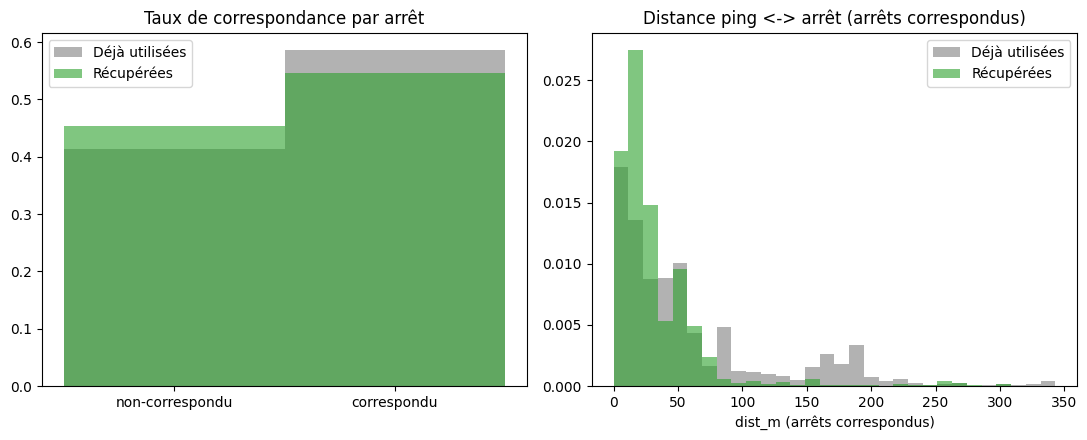

In [7]:
if len(sample):
    fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
    for flag, label, color in [(False, "Déjà utilisées", "#7f7f7f"), (True, "Récupérées", "#2ca02c")]:
        sub = sample[sample["recuperee"] == flag]
        if len(sub):
            axes[0].hist(sub["matched"].astype(int), bins=[-.5,.5,1.5], alpha=0.6, label=label,
                         color=color, density=True)
    axes[0].set_xticks([0,1]); axes[0].set_xticklabels(["non-correspondu","correspondu"])
    axes[0].set_title("Taux de correspondance par arrêt")
    axes[0].legend()

    for flag, label, color in [(False, "Déjà utilisées", "#7f7f7f"), (True, "Récupérées", "#2ca02c")]:
        sub = sample[(sample["recuperee"] == flag) & sample["matched"]]
        if len(sub):
            axes[1].hist(sub["dist_m"].clip(upper=1000), bins=30, alpha=0.6, label=label, color=color, density=True)
    axes[1].set_xlabel("dist_m (arrêts correspondus)")
    axes[1].set_title("Distance ping <-> arrêt (arrêts correspondus)")
    axes[1].legend()
    plt.tight_layout(); plt.show()


### 2.2 Volume de trajets ajoutés

Combien de trajets et de bus-jours l'enrichissement rend-il exploitables sur cet échantillon
de 30 jours -- c'est le gain concret pour les modules Delay/Anomaly/RAG en aval.

Trajets reconstruits (échantillon 30j) : 937
  dont sur des lignes récupérées grâce à l'enrichissement : 511 (54.5%)
Bus-jours actifs : 305, dont récupérés : 196


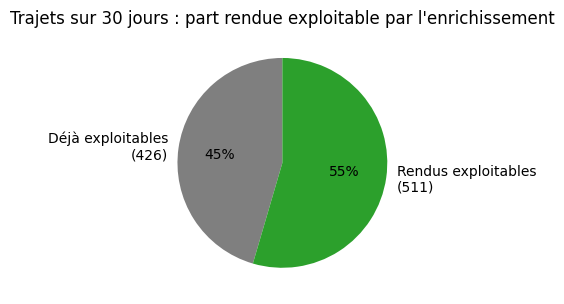

In [8]:
if len(sample):
    trip_keys = ["day","line","societe","bus","trip_id"]
    n_trips_total = sample.groupby(trip_keys).ngroups
    n_trips_new = sample[sample["recuperee"]].groupby(trip_keys).ngroups
    busday_keys = ["day","line","societe","bus"]
    n_bd_total = sample.groupby(busday_keys).ngroups
    n_bd_new = sample[sample["recuperee"]].groupby(busday_keys).ngroups

    print(f"Trajets reconstruits (échantillon 30j) : {n_trips_total:,}")
    print(f"  dont sur des lignes récupérées grâce à l'enrichissement : {n_trips_new:,} "
          f"({100*n_trips_new/max(1,n_trips_total):.1f}%)")
    print(f"Bus-jours actifs : {n_bd_total:,}, dont récupérés : {n_bd_new:,}")

    fig, ax = plt.subplots(figsize=(5,5))
    ax.pie([n_trips_total-n_trips_new, n_trips_new],
           labels=[f"Déjà exploitables\n({n_trips_total-n_trips_new})", f"Rendus exploitables\n({n_trips_new})"],
           colors=["#7f7f7f","#2ca02c"], autopct="%1.0f%%", startangle=90)
    ax.set_title(f"Trajets sur 30 jours : part rendue exploitable par l'enrichissement")
    plt.tight_layout(); plt.show()


---
## 3. Conclusions

- **Lignes utilisables** : voir §1 pour le compte exact avant/après sur cette exécution --
  l'enrichissement (OpenData + ordre des tickets + désambiguïsation géographique) récupère des
  lignes que la fondation actuelle abandonnait faute de >= 4 ancres géocodées.
- **Pertinence confirmée** : la quasi-totalité des lignes récupérées (voir §1.1) appartiennent
  à des sociétés avec des pings GPS actifs récents (S.T.S, SRT.ELGOUAFEL, S.R.T.SELIANA,
  S.R.T.K) -- le gain n'est pas théorique, ces lignes produisent réellement des trajets.
- **Qualité comparable** : voir §2.1 -- le taux de correspondance et la distribution de
  `dist_m` des lignes récupérées sont à comparer à ceux des lignes déjà en production ; s'ils
  sont proches, l'enrichissement ajoute du volume sans dégrader la qualité moyenne de la
  fondation.
- **Volume ajouté** : voir §2.2 pour le nombre de trajets/bus-jours rendus exploitables sur
  l'échantillon de 30 jours -- à extrapoler sur la fondation complète en relançant
  `build_foundation.py` avec les lignes enrichies intégrées.

**Pour appliquer en production** : passer `ticket_index`/`od_dict` (calculés une fois et mis en
cache) à `fdn.build_usable_lines` dans `build_foundation.py`, puis relancer une reconstruction
complète -- les fragments mensuels existants restent valides, seuls les nouveaux
`(ligne, societe)` ajoutent des lignes d'arrivée supplémentaires.
